# 🎬 Automated Content Briefing System
### ThinkFlix ML Challenge
This notebook transforms a long-form article into a structured multimedia briefing with audio narration and a final video.

## Step 1: Install Dependencies

In [1]:
# Run this cell once
!pip install sumy edge-tts moviepy matplotlib pillow nltk imageio imageio-ffmpeg nest_asyncio

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 2: Input Article

In [3]:
ARTICLE_TITLE = "How Large Language Models Work"

ARTICLE_TEXT = """
Large language models, or LLMs, are a class of artificial intelligence systems trained on massive 
amounts of text data to understand and generate human language. They have transformed how we 
interact with computers and are behind systems like ChatGPT, Claude, and Gemini.

At their core, LLMs are built on a neural network architecture called the Transformer, introduced 
by Google researchers in 2017. The Transformer uses a mechanism called self-attention, which 
allows the model to weigh the importance of every word in a sentence relative to every other word. 
This is what gives LLMs their ability to understand context across long passages of text.

Training an LLM involves two main phases. In the pre-training phase, the model is exposed to 
hundreds of billions of words from books, websites, and other sources. It learns by predicting 
the next word in a sequence, adjusting millions or even billions of internal parameters each time 
it makes a mistake. This process requires enormous computing power, often hundreds of GPUs 
running for weeks.

The second phase is fine-tuning, where the pre-trained model is further trained on more specific 
data to make it more helpful, harmless, and honest. A popular technique is Reinforcement Learning 
from Human Feedback, or RLHF, where human raters evaluate model responses and their preferences 
are used to guide further training.

One of the most remarkable properties of LLMs is their emergent capabilities. As models grow 
larger, they begin to exhibit abilities that were not explicitly trained, such as multi-step 
reasoning, code generation, and even rudimentary mathematical problem solving. Researchers do 
not fully understand why this happens, making it one of the most active areas of AI research.

LLMs have significant limitations. They can hallucinate, generating confident but factually 
incorrect information. They have knowledge cutoffs, meaning they are unaware of events after 
their training data ends. They also struggle with tasks requiring precise arithmetic or symbolic 
reasoning.

Despite these limitations, LLMs are already transforming industries. In software development, 
tools like GitHub Copilot assist engineers by auto-completing code. In healthcare, LLMs help 
summarize medical literature. In education, they power personalized tutoring systems.

The future of LLMs likely involves multimodal models that combine text, image, audio, and video 
understanding. Researchers are also working on making models more efficient, reducing the cost 
and energy required to run them. As these systems continue to evolve, understanding how they 
work becomes increasingly important for engineers and decision-makers alike.
"""

## Step 3: Summarize & Structure Content

In [4]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words

LANGUAGE = "english"

def summarize(text, num_sentences=3):
    parser = PlaintextParser.from_string(text, Tokenizer(LANGUAGE))
    stemmer = Stemmer(LANGUAGE)
    summarizer = LsaSummarizer(stemmer)
    summarizer.stop_words = get_stop_words(LANGUAGE)
    summary = summarizer(parser.document, num_sentences)
    return " ".join(str(s) for s in summary)

# Split article into rough thirds for intro / body / summary
sentences_all = ARTICLE_TEXT.strip().split(". ")
third = len(sentences_all) // 3

intro_text   = ". ".join(sentences_all[:third])
body_text    = ". ".join(sentences_all[third:2*third])
closing_text = ". ".join(sentences_all[2*third:])

intro_summary   = summarize(intro_text, 2)
body_summary    = summarize(body_text, 3)
closing_summary = summarize(closing_text, 2)

SECTIONS = [
    {
        "title": "Introduction",
        "subtitle": "What are Large Language Models?",
        "content": intro_summary
    },
    {
        "title": "Key Points",
        "subtitle": "How Training Works",
        "content": body_summary
    },
    {
        "title": "Summary",
        "subtitle": "Impact & Future Directions",
        "content": closing_summary
    }
]

for s in SECTIONS:
    print(f"\n=== {s['title']}: {s['subtitle']} ===")
    print(s['content'])


=== Introduction: What are Large Language Models? ===
At their core, LLMs are built on a neural network architecture called the Transformer, introduced by Google researchers in 2017. It learns by predicting the next word in a sequence, adjusting millions or even billions of internal parameters each time it makes a mistake

=== Key Points: How Training Works ===
This process requires enormous computing power, often hundreds of GPUs running for weeks. The second phase is fine-tuning, where the pre-trained model is further trained on more specific data to make it more helpful, harmless, and honest. As models grow larger, they begin to exhibit abilities that were not explicitly trained, such as multi-step reasoning, code generation, and even rudimentary mathematical problem solving.

=== Summary: Impact & Future Directions ===
The future of LLMs likely involves multimodal models that combine text, image, audio, and video understanding. Researchers are also working on making models more ef

## Step 4: Generate Audio Narration

In [5]:
import nest_asyncio
import asyncio
import edge_tts
import os

nest_asyncio.apply()
os.makedirs("output", exist_ok=True)

VOICE = "en-US-AriaNeural"  # Free, high quality Microsoft voice

# Build full narration script
narration_parts = []
narration_parts.append(f"Welcome to this briefing on: {ARTICLE_TITLE}.")

for section in SECTIONS:
    narration_parts.append(f"{section['title']}. {section['subtitle']}.")
    narration_parts.append(section['content'])

narration_parts.append("That concludes this automated briefing. Thank you for watching.")

AUDIO_FILES = []

async def generate_audio(text, filename):
    communicate = edge_tts.Communicate(text, VOICE)
    await communicate.save(filename)

# Generate one audio file per narration part
for i, part in enumerate(narration_parts):
    fname = f"output/narration_{i:02d}.mp3"
    asyncio.run(generate_audio(part, fname))
    AUDIO_FILES.append(fname)
    print(f"Generated: {fname}")

print("\n✅ All audio files generated!")

Generated: output/narration_00.mp3


Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\Owner\AppData\Local\Programs\Python\Python314\Lib\asyncio\events.py", line 94, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000001C605BB3FC0> is already entered


Generated: output/narration_01.mp3
Generated: output/narration_02.mp3
Generated: output/narration_03.mp3
Generated: output/narration_04.mp3
Generated: output/narration_05.mp3
Generated: output/narration_06.mp3
Generated: output/narration_07.mp3

✅ All audio files generated!


## Step 5: Merge Audio Files

In [6]:
from moviepy.editor import AudioFileClip, concatenate_audioclips

clips = [AudioFileClip(f) for f in AUDIO_FILES]
full_audio = concatenate_audioclips(clips)
full_audio.write_audiofile("output/full_narration.mp3")
print(f"\n✅ Full narration duration: {full_audio.duration:.1f} seconds")

MoviePy - Writing audio in output/full_narration.mp3


MoviePy - Done.

✅ Full narration duration: 83.7 seconds


## Step 6: Generate Slide Images

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

SLIDE_FILES = []

def make_title_slide(title, output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Accent bar
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.44), 0.9, 0.005,
        boxstyle="round,pad=0", color='#4A9EFF'))

    ax.text(0.5, 0.62, title, ha='center', va='center',
            fontsize=34, fontweight='bold', color='white', wrap=True)
    ax.text(0.5, 0.35, 'Automated Content Briefing', ha='center',
            fontsize=16, color='#4A9EFF')
    ax.text(0.5, 0.22, 'Powered by open-source NLP + TTS', ha='center',
            fontsize=12, color='#888888')

    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

def make_section_slide(section_title, subtitle, content, output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Section label pill
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.82), 0.22, 0.07,
        boxstyle="round,pad=0.01", color='#4A9EFF', alpha=0.2))
    ax.text(0.16, 0.857, section_title, ha='center', va='center',
            fontsize=13, color='#4A9EFF', fontweight='bold')

    # Title
    ax.text(0.05, 0.73, subtitle, ha='left', va='center',
            fontsize=26, fontweight='bold', color='white')

    # Divider
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.68), 0.9, 0.003,
        boxstyle="round,pad=0", color='#333333'))

    # Content text wrapped
    wrapped = textwrap.fill(content, width=90)
    ax.text(0.05, 0.55, wrapped, ha='left', va='top',
            fontsize=14, color='#CCCCCC', linespacing=1.8,
            transform=ax.transAxes, wrap=True)

    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

def make_end_slide(output_path):
    fig, ax = plt.subplots(figsize=(12.8, 7.2), facecolor='#0D1117')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.55, 'Thank You', ha='center', va='center',
            fontsize=42, fontweight='bold', color='white')
    ax.text(0.5, 0.38, 'End of Briefing', ha='center',
            fontsize=18, color='#4A9EFF')
    plt.tight_layout(pad=0)
    plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.close()

# Generate title slide
make_title_slide(ARTICLE_TITLE, "output/slide_00_title.png")
SLIDE_FILES.append("output/slide_00_title.png")

# Generate section slides
for i, section in enumerate(SECTIONS):
    path = f"output/slide_{i+1:02d}_{section['title'].lower()}.png"
    make_section_slide(section['title'], section['subtitle'], section['content'], path)
    SLIDE_FILES.append(path)

# Generate end slide
make_end_slide("output/slide_05_end.png")
SLIDE_FILES.append("output/slide_05_end.png")

print(f"✅ Generated {len(SLIDE_FILES)} slides:")
for f in SLIDE_FILES:
    print(f"  {f}")

✅ Generated 5 slides:
  output/slide_00_title.png
  output/slide_01_introduction.png
  output/slide_02_key points.png
  output/slide_03_summary.png
  output/slide_05_end.png


## Step 7: Assemble Final Video

In [10]:
from moviepy.editor import ImageClip, AudioFileClip, concatenate_videoclips, CompositeAudioClip

# Map each slide to its correct audio files
slide_audio_map = [
    [AUDIO_FILES[0]],          # Title slide → welcome
    [AUDIO_FILES[1], AUDIO_FILES[2]],   # Intro slide → header + content
    [AUDIO_FILES[3], AUDIO_FILES[4]],   # Key Points slide → header + content
    [AUDIO_FILES[5], AUDIO_FILES[6]],   # Summary slide → header + content
    [AUDIO_FILES[7]],          # End slide → goodbye
]

video_clips = []

for slide_path, audio_files in zip(SLIDE_FILES, slide_audio_map):
    # Merge audio clips for this slide
    audio_clips = [AudioFileClip(f) for f in audio_files]
    merged_audio = concatenate_audioclips(audio_clips)
    
    # Create video clip matching the audio duration
    clip = ImageClip(slide_path).set_duration(merged_audio.duration).set_audio(merged_audio)
    video_clips.append(clip)

# Assemble final video
final_video = concatenate_videoclips(video_clips, method='compose')
final_video.write_videofile("output/briefing_final.mp4", fps=24, codec='libx264', audio_codec='aac')

print("✅ Done! Slides and audio are now synced.")

Moviepy - Building video output/briefing_final.mp4.
MoviePy - Writing audio in briefing_finalTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video output/briefing_final.mp4



Moviepy - Done !
Moviepy - video ready output/briefing_final.mp4
✅ Done! Slides and audio are now synced.


## Step 8: Preview Slides (Optional)

output/slide_00_title.png


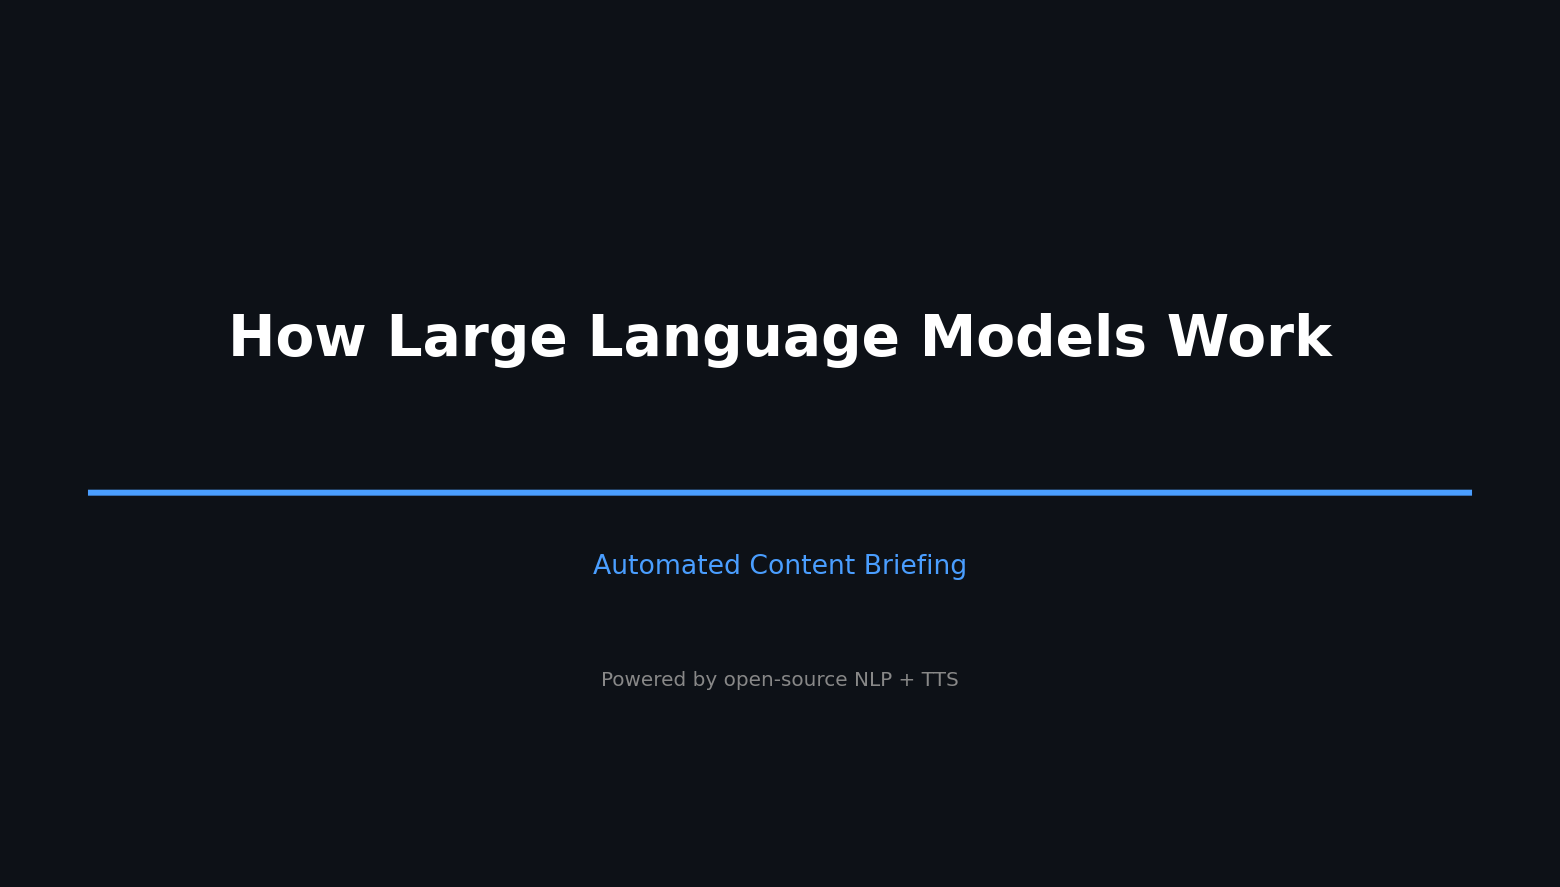

output/slide_01_introduction.png


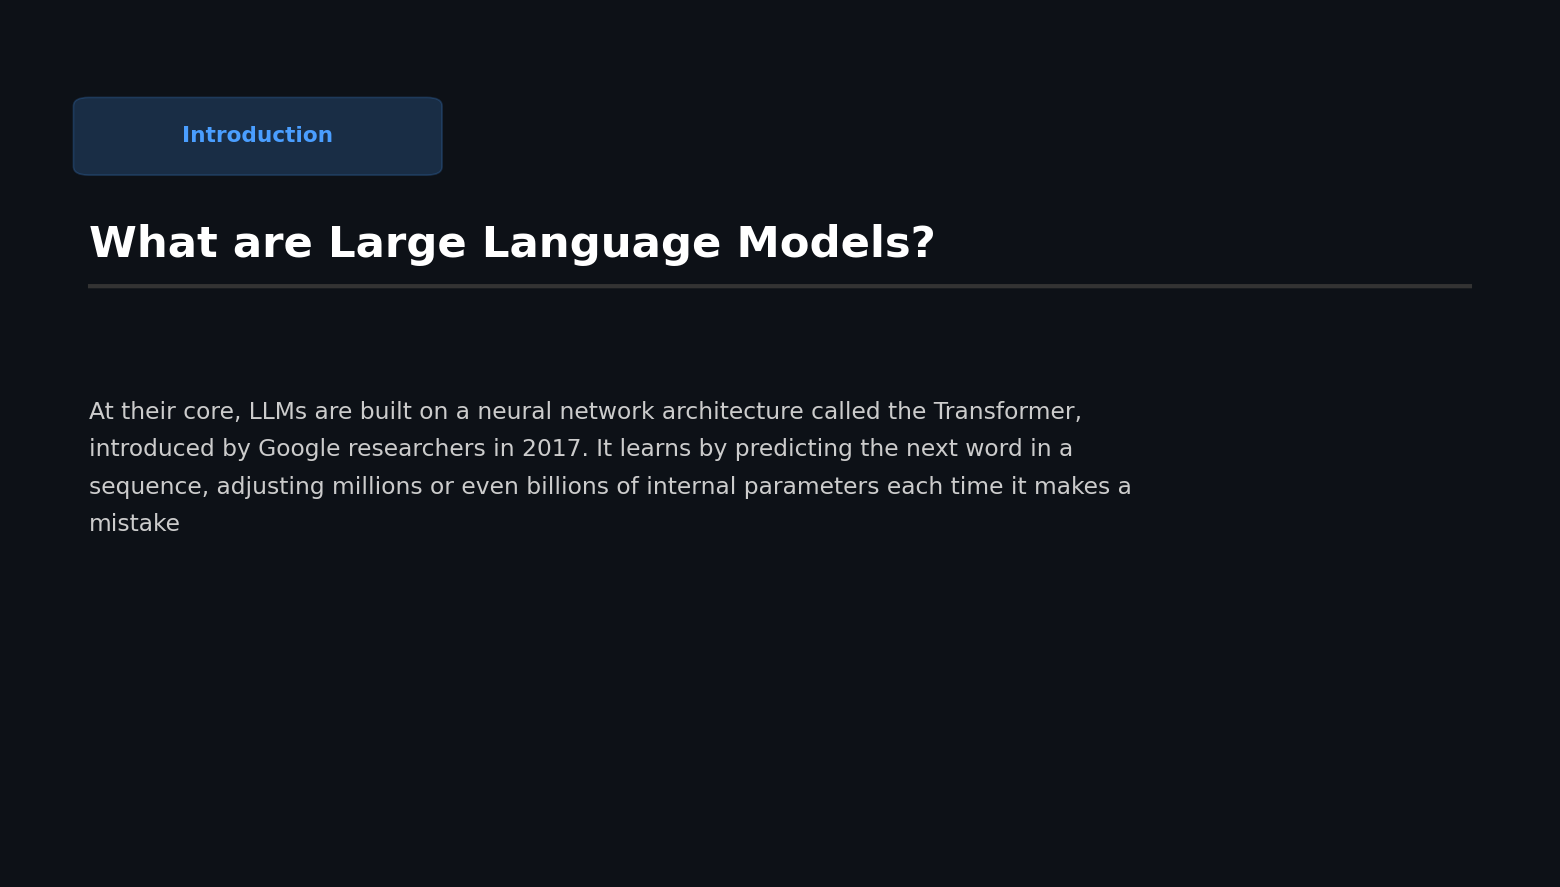

output/slide_02_key points.png


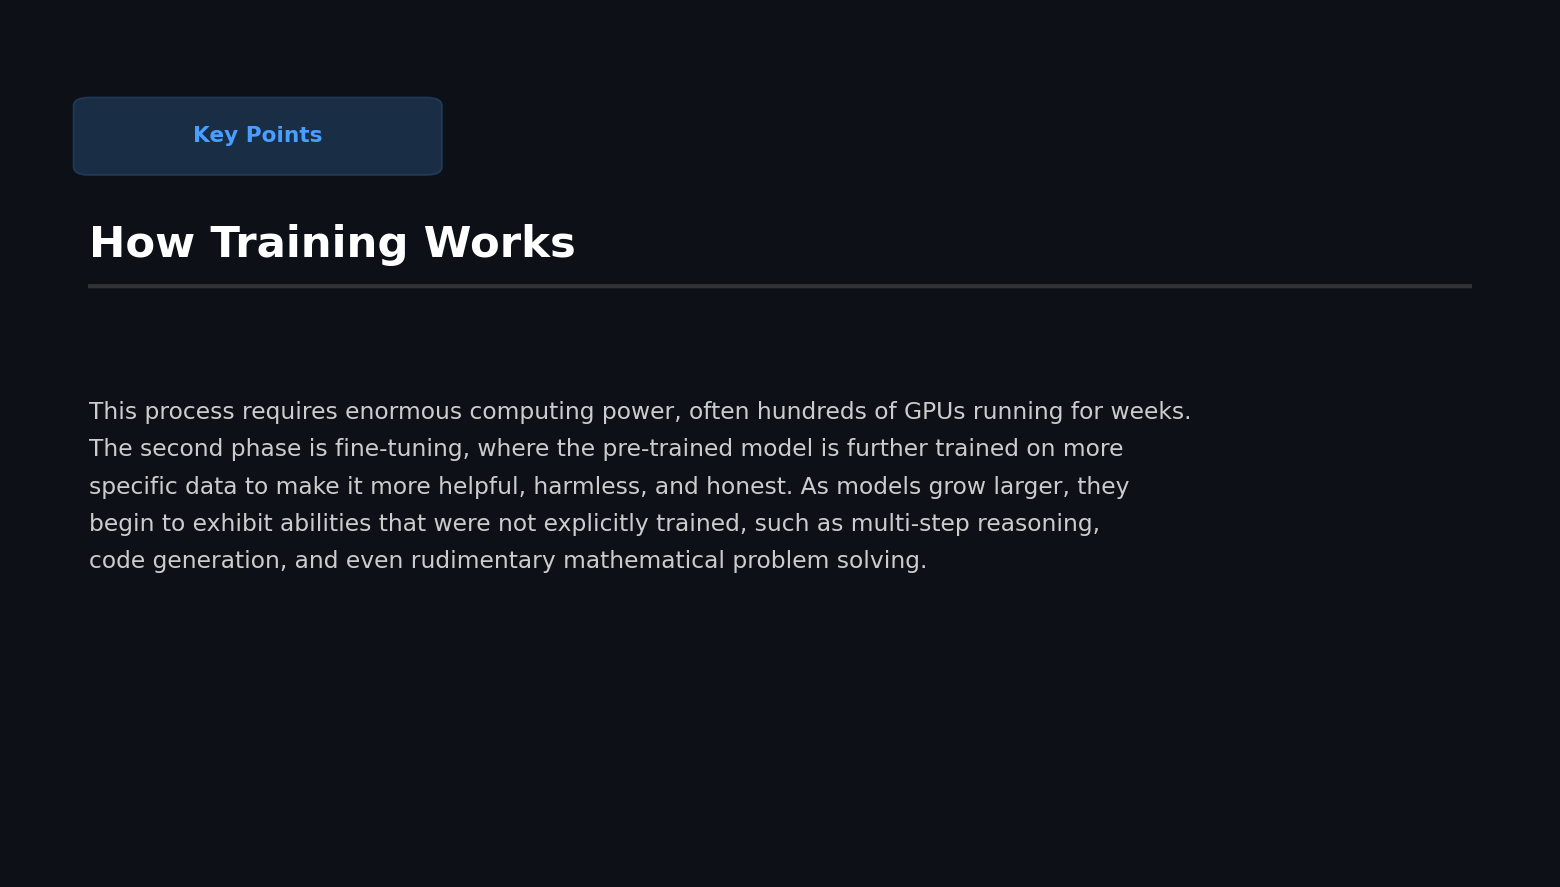

output/slide_03_summary.png


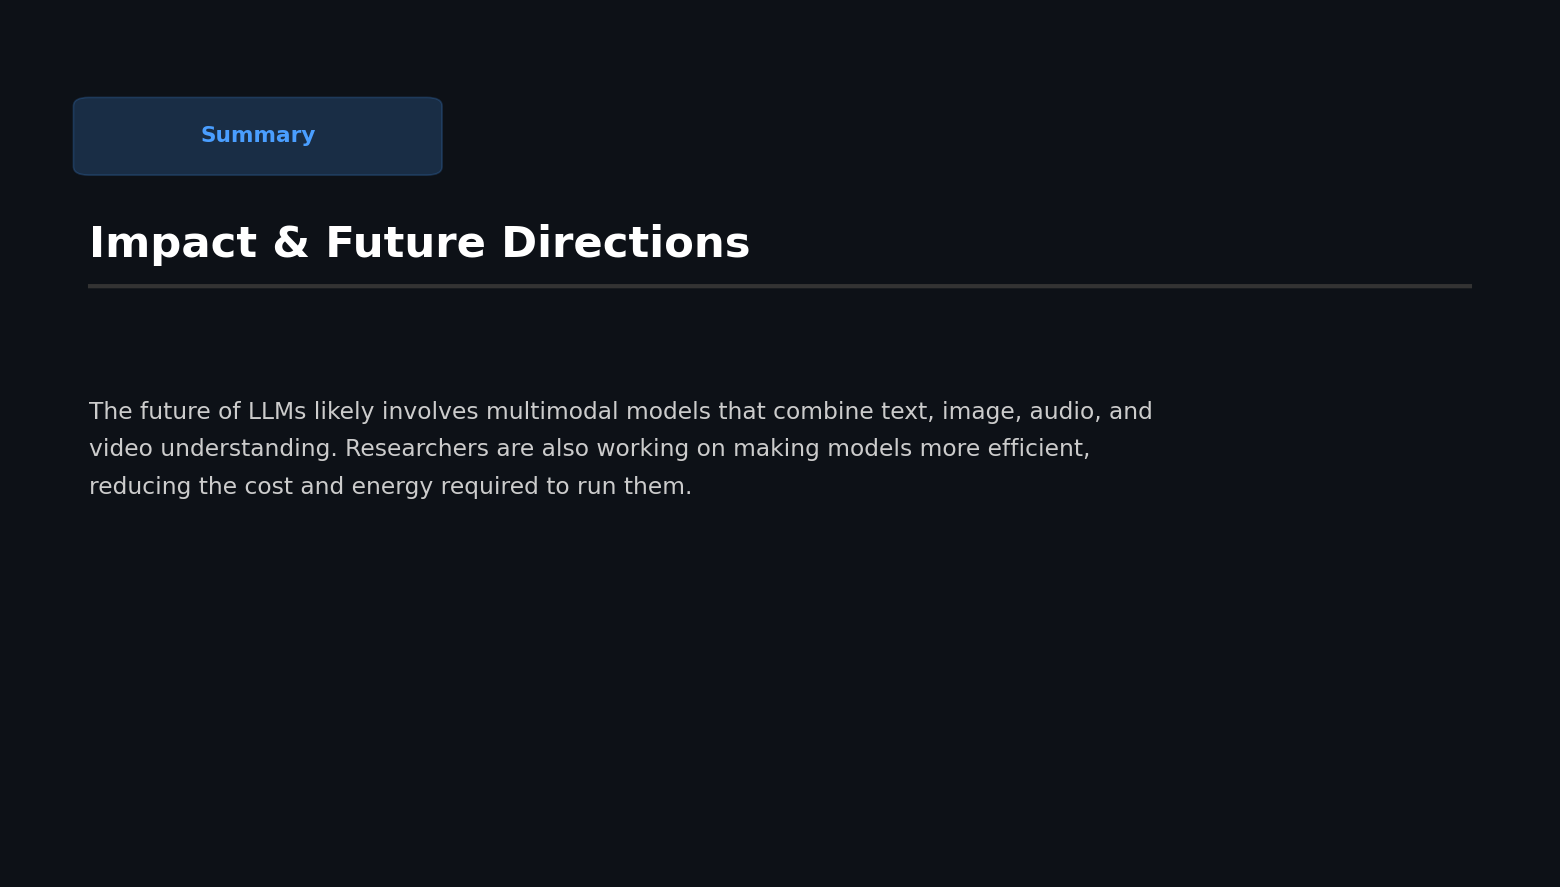

output/slide_05_end.png


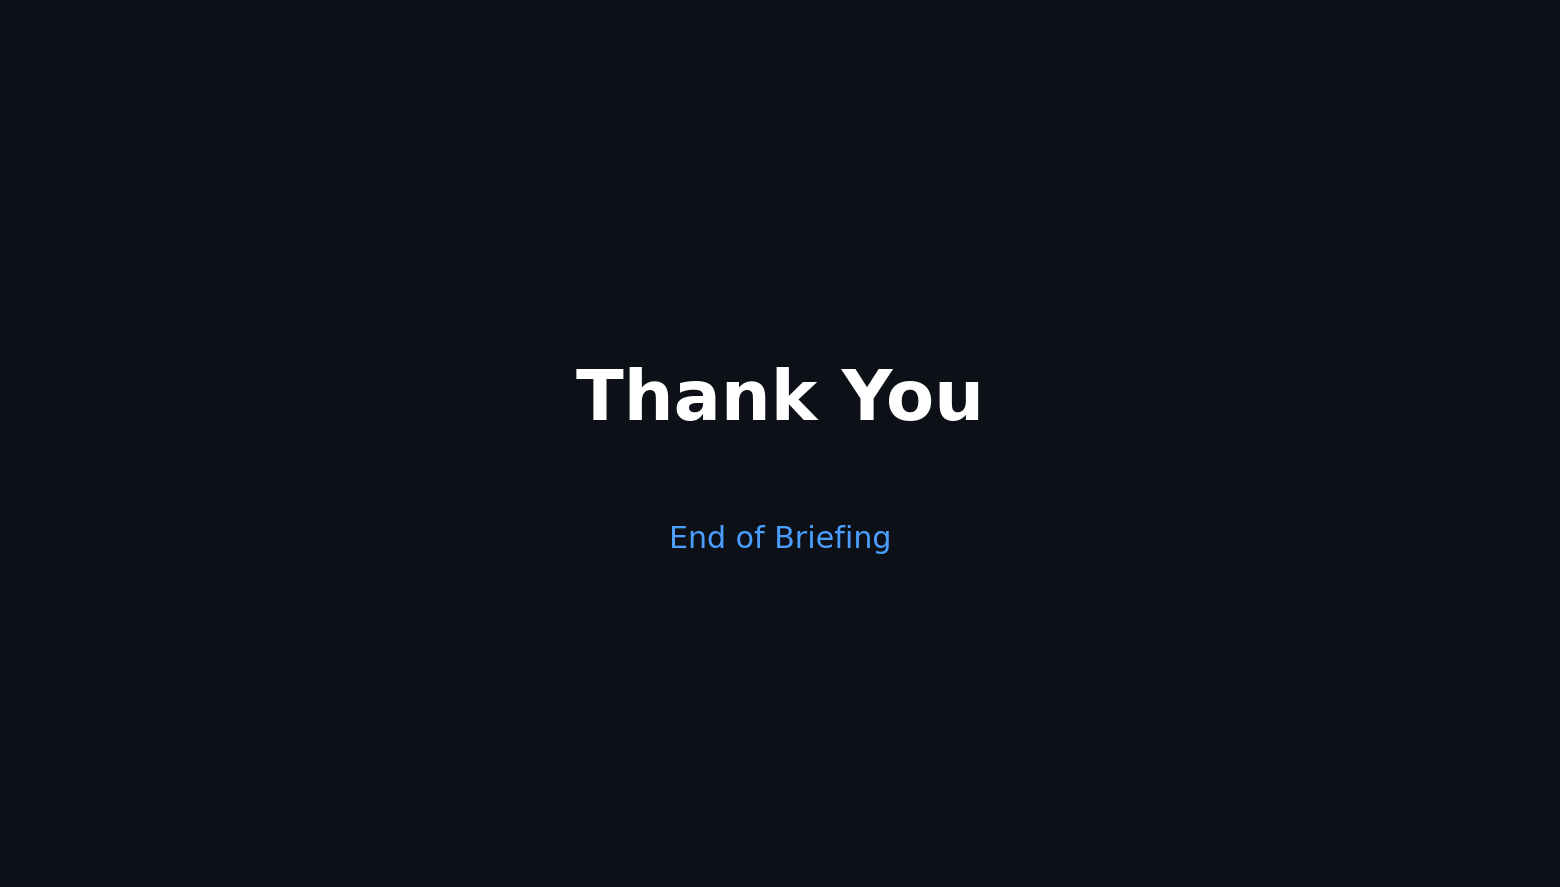

In [9]:
from IPython.display import Image, display

for slide in SLIDE_FILES:
    print(slide)
    display(Image(filename=slide, width=700))

---
## ✅ Done!
Your final video is at `output/briefing_final.mp4`.

**Pipeline Summary:**
| Step | Tool | Cost |
|------|------|------|
| Summarization | `sumy` (LSA) | Free |
| Text-to-Speech | `edge-tts` (Microsoft Neural) | Free |
| Slide Generation | `matplotlib` | Free |
| Video Assembly | `moviepy` + `ffmpeg` | Free |

**Total cost: $0.00**